In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

In [3]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith((".keras", ".h5")):
            print(os.path.join(root, file))

In [4]:
for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith((".keras", ".h5")):
            print(os.path.join(root, file))

..\models\baseline_mobilenetv3.keras
..\models\best_custom_cnn.keras
..\models\best_mobilenetv3.keras
..\models\best_resnet50.keras
..\models\final_resnet50.keras
..\venv\Lib\site-packages\h5py\tests\data_files\vlen_string_dset.h5
..\venv\Lib\site-packages\h5py\tests\data_files\vlen_string_dset_utc.h5
..\venv\Lib\site-packages\h5py\tests\data_files\vlen_string_s390x.h5


In [6]:
MODEL_PATH = "../models/final_resnet50.keras"

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model loaded successfully")

Model loaded successfully


In [8]:
best_model = tf.keras.models.load_model(
    "../models/best_resnet50.keras",
    compile=False
)

final_model = tf.keras.models.load_model(
    "../models/final_resnet50.keras",
    compile=False
)

In [10]:
best_results = best_model.evaluate(
    val_ds,
    verbose=0
)

final_results = final_model.evaluate(
    val_ds,
    verbose=0
)

print("Best model results:", best_results)
print("Final model results:", final_results)

NameError: name 'val_ds' is not defined

In [11]:
model = tf.keras.models.load_model(
    "../models/final_resnet50.keras",
    compile=False
)

In [12]:
model.summary()

Model: "resnet50_fall_detection"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fall_probability    │ (None, 1)         │      2,049 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
for index, layer in enumerate(model.layers):
    try:
        print(
            index,
            layer.name,
            layer.__class__.__name__,
            layer.output.shape
        )
    except Exception:
        print(
            index,
            layer.name,
            layer.__class__.__name__
        )

0 input_image InputLayer (None, 224, 224, 3)
1 data_augmentation Sequential (None, 224, 224, 3)
2 resnet50 Functional (None, 7, 7, 2048)
3 global_average_pooling2d_1 GlobalAveragePooling2D (None, 2048)
4 dropout_1 Dropout (None, 2048)
5 fall_probability Dense (None, 1)


In [14]:
target_layer = model.get_layer("resnet50")

print("Target layer:", target_layer.name)
print("Output shape:", target_layer.output.shape)

Target layer: resnet50
Output shape: (None, 7, 7, 2048)


In [15]:
def generate_gradcam_heatmap(
    model,
    image_batch,
    target_layer,
    target_class=1
):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            target_layer.output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        feature_maps, predictions = grad_model(
            image_batch,
            training=False
        )

        prediction = tf.squeeze(predictions)

        if target_class == 1:
            class_score = prediction
        else:
            class_score = 1.0 - prediction

    gradients = tape.gradient(
        class_score,
        feature_maps
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(
        feature_maps * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), float(prediction.numpy())

In [16]:
def load_image_for_model(image_path, image_size=(224, 224)):
    original_image = tf.keras.utils.load_img(image_path)

    resized_image = tf.keras.utils.load_img(
        image_path,
        target_size=image_size
    )

    image_array = tf.keras.utils.img_to_array(resized_image)

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    return original_image, image_batch

In [17]:
import os

VAL_FALL_PATH = "../data/processed/val/fall"

fall_images = os.listdir(VAL_FALL_PATH)

print(fall_images[:10])

['fdc_rgb_0609.png', 'fdc_rgb_0625.png', 'fdc_rgb_0641.png', 'fdc_rgb_0657.png', 'fdc_rgb_0673.png', 'fdc_rgb_0689.png', 'fdc_rgb_0705.png', 'fdc_rgb_0721.png', 'fdc_rgb_0737.png', 'fdc_rgb_0753.png']


In [18]:
IMAGE_PATH = os.path.join(
    VAL_FALL_PATH,
    fall_images[0]
)

print(IMAGE_PATH)

../data/processed/val/fall\fdc_rgb_0609.png


In [19]:
original_image, image_batch = load_image_for_model(
    IMAGE_PATH,
    image_size=(224, 224)
)

print("Image batch shape:", image_batch.shape)

Image batch shape: (1, 224, 224, 3)


In [20]:
prediction_score = float(
    model.predict(
        image_batch,
        verbose=0
    )[0][0]
)

print("Raw prediction score:", prediction_score)

Raw prediction score: 0.9004315733909607


In [21]:
if prediction_score >= 0.5:
    predicted_class = "Fall"
    target_class = 1
    confidence = prediction_score
else:
    predicted_class = "No Fall"
    target_class = 0
    confidence = 1 - prediction_score

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

Predicted class: Fall
Confidence: 90.04%


In [23]:
def generate_gradcam_heatmap(
    model,
    image_batch,
    target_class=1
):
    # Get the layers from your complete model
    augmentation_layer = model.get_layer("data_augmentation")
    backbone = model.get_layer("resnet50")
    pooling_layer = model.get_layer("global_average_pooling2d_1")
    dropout_layer = model.get_layer("dropout_1")
    output_layer = model.get_layer("fall_probability")

    with tf.GradientTape() as tape:
        # Follow exactly the same path as the original model
        x = augmentation_layer(
            image_batch,
            training=False
        )

        feature_maps = backbone(
            x,
            training=False
        )

        # Tell TensorFlow to track the feature maps
        tape.watch(feature_maps)

        x = pooling_layer(feature_maps)

        x = dropout_layer(
            x,
            training=False
        )

        predictions = output_layer(x)

        prediction = tf.squeeze(predictions)

        # Explain the selected class
        if target_class == 1:
            class_score = prediction
        else:
            class_score = 1.0 - prediction

    gradients = tape.gradient(
        class_score,
        feature_maps
    )

    if gradients is None:
        raise ValueError(
            "Gradients could not be calculated."
        )

    # Average gradient for each feature-map channel
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    feature_maps = feature_maps[0]

    # Weight each channel using its average gradient
    heatmap = tf.reduce_sum(
        feature_maps * pooled_gradients,
        axis=-1
    )

    # Keep only positive influence
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize between 0 and 1
    maximum_value = tf.reduce_max(heatmap)

    if maximum_value > 0:
        heatmap = heatmap / maximum_value

    return heatmap.numpy(), float(prediction.numpy())

In [24]:
heatmap, score = generate_gradcam_heatmap(
    model=model,
    image_batch=image_batch,
    target_class=target_class
)

Heatmap shape: (7, 7)
Prediction score: 0.8296258449554443


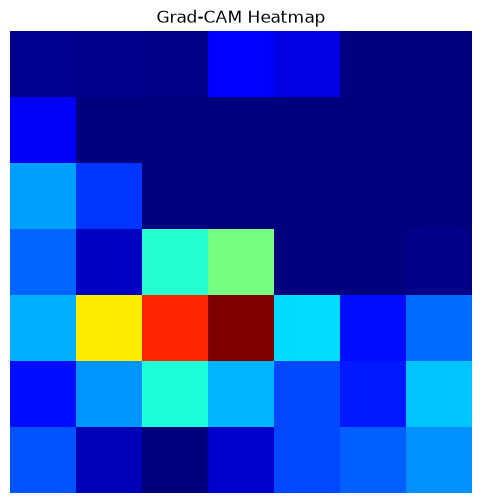

In [26]:
print("Heatmap shape:", heatmap.shape)
print("Prediction score:", score)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

In [27]:
overlay_image = overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
)

plt.figure(figsize=(8,8))
plt.imshow(overlay_image)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")
plt.show()

NameError: name 'overlay_gradcam' is not defined

In [28]:
def overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
):
    original_array = np.array(
        original_image.convert("RGB")
    )

    heatmap_tensor = tf.convert_to_tensor(
        heatmap[..., np.newaxis],
        dtype=tf.float32
    )

    resized_heatmap = tf.image.resize(
        heatmap_tensor,
        (
            original_array.shape[0],
            original_array.shape[1]
        )
    ).numpy().squeeze()

    colormap = plt.get_cmap("jet")

    coloured_heatmap = colormap(
        resized_heatmap
    )[:, :, :3]

    coloured_heatmap = (
        coloured_heatmap * 255
    ).astype(np.uint8)

    overlay = (
        (1 - alpha) * original_array
        + alpha * coloured_heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        255
    ).astype(np.uint8)

    return overlay

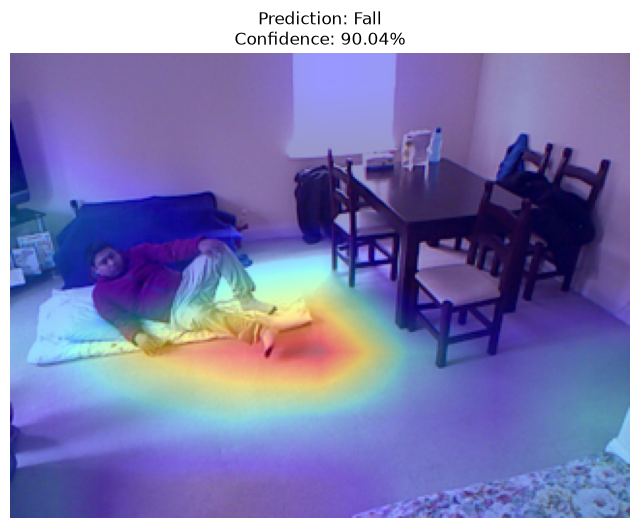

In [29]:
overlay_image = overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
)

plt.figure(figsize=(8, 8))
plt.imshow(overlay_image)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")
plt.show()

In [30]:
from pathlib import Path
from PIL import Image

output_dir = Path("../outputs/gradcam")
output_dir.mkdir(parents=True, exist_ok=True)

Image.fromarray(overlay_image).save(
    output_dir / "correct_fall_1.png"
)

print("Saved Correct Fall 1")

Saved Correct Fall 1


In [31]:
def run_gradcam_analysis(
    image_path,
    actual_class,
    save_name,
    model,
    output_directory="../outputs/gradcam",
    threshold=0.5
):
    original_image, image_batch = load_image_for_model(
        image_path,
        image_size=(224, 224)
    )

    prediction_score = float(
        model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    if prediction_score >= threshold:
        predicted_class = "Fall"
        target_class = 1
        confidence = prediction_score
    else:
        predicted_class = "No Fall"
        target_class = 0
        confidence = 1 - prediction_score

    heatmap, _ = generate_gradcam_heatmap(
        model=model,
        image_batch=image_batch,
        target_class=target_class
    )

    overlay_image = overlay_gradcam(
        original_image,
        heatmap,
        alpha=0.4
    )

    output_directory = Path(output_directory)
    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    save_path = output_directory / f"{save_name}.png"

    Image.fromarray(
        overlay_image
    ).save(save_path)

    print("Actual class:", actual_class)
    print("Predicted class:", predicted_class)
    print("Confidence:", f"{confidence:.2%}")
    print("Saved to:", save_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay_image)

    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.axis("off")
    plt.show()

    return {
        "image_path": str(image_path),
        "actual_class": actual_class,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "raw_score": prediction_score,
        "save_path": str(save_path)
    }

Actual class: Fall
Predicted class: Fall
Confidence: 90.04%
Saved to: ..\outputs\gradcam\correct_fall_1.png


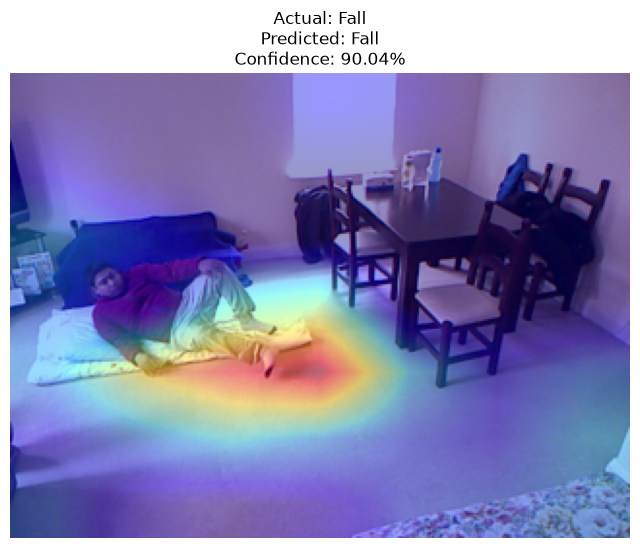

In [32]:
result_1 = run_gradcam_analysis(
    image_path=IMAGE_PATH,
    actual_class="Fall",
    save_name="correct_fall_1",
    model=model
)

In [33]:
import os

fall_folder = "../data/processed/val/fall"
fall_files = os.listdir(fall_folder)

for filename in fall_files[:20]:
    image_path = os.path.join(
        fall_folder,
        filename
    )

    _, image_batch = load_image_for_model(
        image_path,
        image_size=(224, 224)
    )

    score = float(
        model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    if score >= 0.5:
        print(filename, score)

fdc_rgb_0609.png 0.9004315733909607
fdc_rgb_0625.png 0.9055050015449524
fdc_rgb_0641.png 0.8554646968841553
fdc_rgb_0657.png 0.8676593899726868
fdc_rgb_0673.png 0.8912127614021301
fdc_rgb_0689.png 0.8600921630859375
fdc_rgb_0705.png 0.8698222637176514
fdc_rgb_0721.png 0.854568362236023
fdc_rgb_0737.png 0.8736259937286377
fdc_rgb_0753.png 0.797802209854126
fdc_rgb_0769.png 0.9107106328010559
fdc_rgb_0785.png 0.9045107364654541
fdc_rgb_0817.png 0.8422355651855469
fdc_rgb_0833.png 0.8660089373588562
fdc_rgb_0849.png 0.7800682783126831
fdc_rgb_0865.png 0.840548574924469
fdc_rgb_0881.png 0.8467530012130737
fdc_rgb_0897.png 0.8318783044815063
fdc_rgb_0913.png 0.8529098033905029
fdc_rgb_0929.png 0.842124342918396


Actual class: Fall
Predicted class: Fall
Confidence: 79.78%
Saved to: ..\outputs\gradcam\correct_fall_2.png


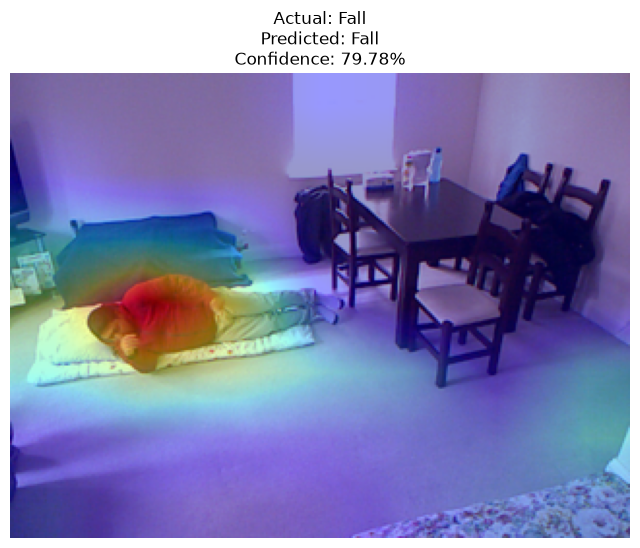

In [38]:
result_2 = run_gradcam_analysis(
    image_path="../data/processed/val/fall/fdc_rgb_0753.png",
    actual_class="Fall",
    save_name="correct_fall_2",
    model=model
)

In [39]:
no_fall_folder = "../data/processed/val/no_fall"
no_fall_files = os.listdir(no_fall_folder)

correct_no_fall_paths = []

for filename in no_fall_files:
    image_path = os.path.join(
        no_fall_folder,
        filename
    )

    _, image_batch = load_image_for_model(
        image_path,
        image_size=(224, 224)
    )

    score = float(
        model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    if score < 0.5:
        correct_no_fall_paths.append(image_path)

    if len(correct_no_fall_paths) == 2:
        break

print(correct_no_fall_paths)

['../data/processed/val/no_fall\\fdc_rgb_0145.png', '../data/processed/val/no_fall\\fdc_rgb_0217.png']


Actual class: No Fall
Predicted class: No Fall
Confidence: 58.61%
Saved to: ..\outputs\gradcam\correct_no_fall_1.png


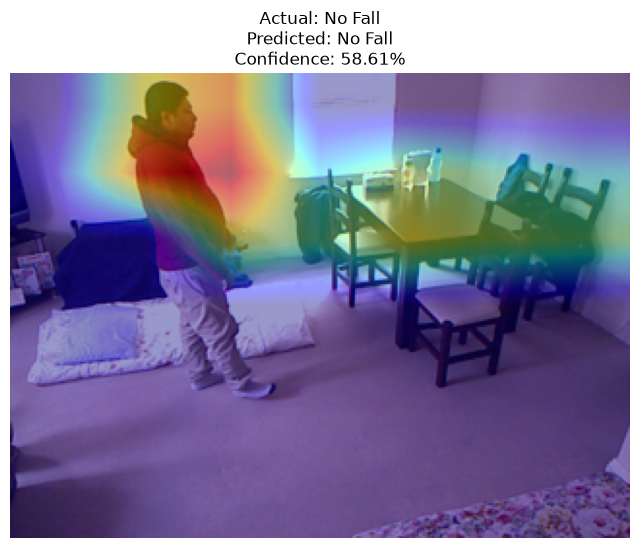

In [40]:
result_3 = run_gradcam_analysis(
    image_path=correct_no_fall_paths[0],
    actual_class="No Fall",
    save_name="correct_no_fall_1",
    model=model
)

Actual class: No Fall
Predicted class: No Fall
Confidence: 80.94%
Saved to: ..\outputs\gradcam\correct_no_fall_2.png


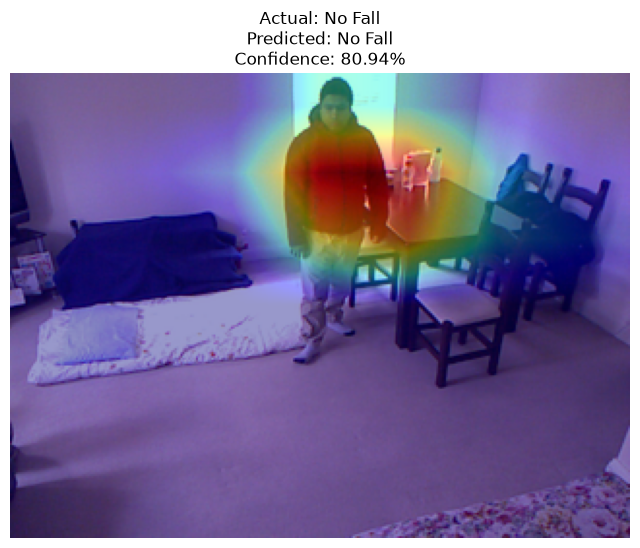

In [41]:
result_4 = run_gradcam_analysis(
    image_path=correct_no_fall_paths[1],
    actual_class="No Fall",
    save_name="correct_no_fall_2",
    model=model
)

In [42]:
false_positive_paths = []

for filename in no_fall_files:
    image_path = os.path.join(
        no_fall_folder,
        filename
    )

    _, image_batch = load_image_for_model(
        image_path,
        image_size=(224, 224)
    )

    score = float(
        model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    if score >= 0.5:
        false_positive_paths.append(image_path)

    if len(false_positive_paths) == 2:
        break

print(false_positive_paths)

['../data/processed/val/no_fall\\fdc_rgb_0073.png', '../data/processed/val/no_fall\\fdc_rgb_0109.png']


Actual class: No Fall
Predicted class: Fall
Confidence: 57.22%
Saved to: ..\outputs\gradcam\false_positive_1.png


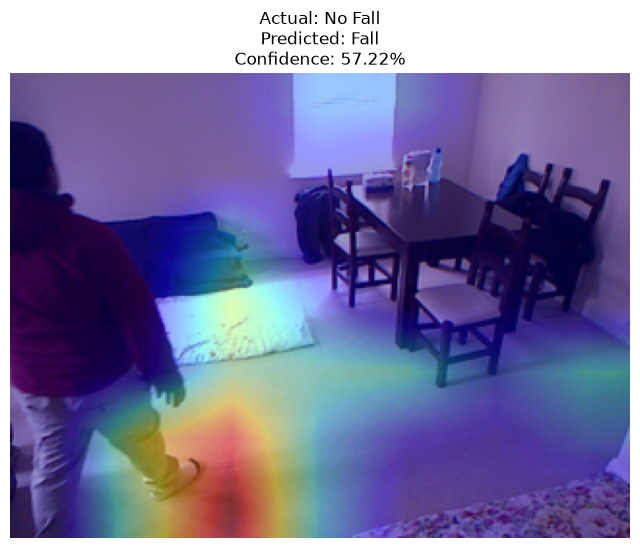

In [43]:
result_5 = run_gradcam_analysis(
    image_path=false_positive_paths[0],
    actual_class="No Fall",
    save_name="false_positive_1",
    model=model
)

Actual class: No Fall
Predicted class: Fall
Confidence: 73.03%
Saved to: ..\outputs\gradcam\false_positive_2.png


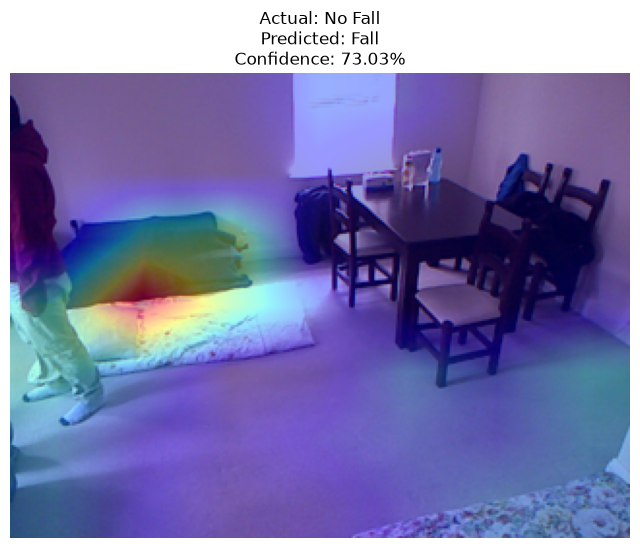

In [44]:
result_6 = run_gradcam_analysis(
    image_path=false_positive_paths[1],
    actual_class="No Fall",
    save_name="false_positive_2",
    model=model
)

In [46]:
false_negative_paths = []

for filename in fall_files:
    image_path = os.path.join(
        fall_folder,
        filename
    )

    _, image_batch = load_image_for_model(
        image_path,
        image_size=(224, 224)
    )

    score = float(
        model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    if score < 0.5:
        false_negative_paths.append(image_path)

    if len(false_negative_paths) == 2:
        break

print(false_negative_paths)

['../data/processed/val/fall\\orig_fall019.jpg', '../data/processed/val/fall\\orig_fall022.jpg']


Actual class: Fall
Predicted class: No Fall
Confidence: 58.90%
Saved to: ..\outputs\gradcam\false_negative_1.png


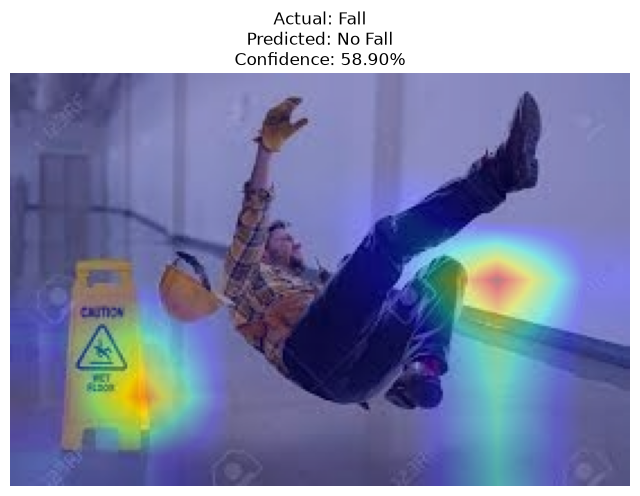

In [48]:
result_7 = run_gradcam_analysis(
    image_path=false_negative_paths[0],
    actual_class="Fall",
    save_name="false_negative_1",
    model=model
)

Actual class: Fall
Predicted class: No Fall
Confidence: 72.36%
Saved to: ..\outputs\gradcam\false_negative_2.png


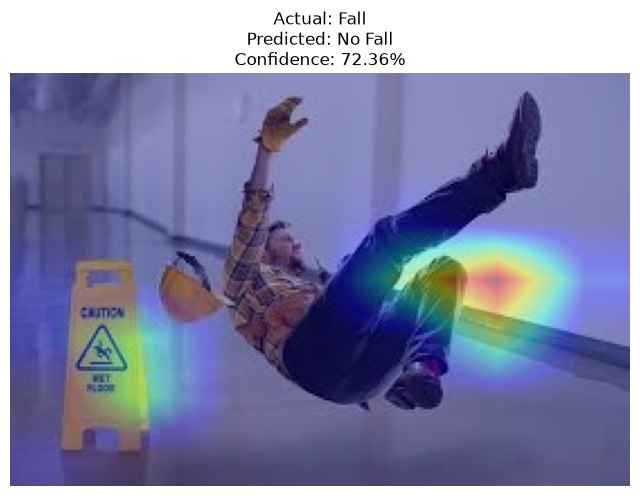

In [49]:
result_8 = run_gradcam_analysis(
    image_path=false_negative_paths[1],
    actual_class="Fall",
    save_name="false_negative_2",
    model=model
)

In [50]:
import pandas as pd

gradcam_results = pd.DataFrame([
    result_1,
    result_2,
    result_3,
    result_4,
    result_5,
    result_6,
    result_7,
    result_8
])

gradcam_results

,image_path,actual_class,predicted_class,confidence,raw_score,save_path
0,../data/processed/val/fall\fdc_rgb_0609.png,Fall,Fall,0.900432,0.900432,..\outputs\gradcam\correct_fall_1.png
1,../data/processed/val/fall/fdc_rgb_0753.png,Fall,Fall,0.797802,0.797802,..\outputs\gradcam\correct_fall_2.png
2,../data/processed/val/no_fall\fdc_rgb_0145.png,No Fall,No Fall,0.586150,0.413850,..\outputs\gradcam\correct_no_fall_1.png
3,../data/processed/val/no_fall\fdc_rgb_0217.png,No Fall,No Fall,0.809445,0.190555,..\outputs\gradcam\correct_no_fall_2.png
4,../data/processed/val/no_fall\fdc_rgb_0073.png,No Fall,Fall,0.572176,0.572176,..\outputs\gradcam\false_positive_1.png
5,../data/processed/val/no_fall\fdc_rgb_0109.png,No Fall,Fall,0.730337,0.730337,..\outputs\gradcam\false_positive_2.png
6,../data/processed/val/fall\orig_fall019.jpg,Fall,No Fall,0.589010,0.410990,..\outputs\gradcam\false_negative_1.png
7,../data/processed/val/fall\orig_fall022.jpg,Fall,No Fall,0.723587,0.276413,..\outputs\gradcam\false_negative_2.png


In [51]:
gradcam_results.to_csv(
    "../outputs/gradcam/gradcam_results.csv",
    index=False
)

In [53]:
gradcam_results["observation"] = [
    "Focused on lower body, legs and floor-contact region.",
    "Focused mainly on the torso and lower limbs.",
    "Attention was concentrated on the upright human posture.",
    "Model focused on the person rather than background objects.",
    "Horizontal posture and nearby floor influenced the false alert.",
    "Background or furniture may have contributed to the false prediction.",
    "Important body regions received limited attention.",
    "Occlusion or unusual posture may have caused the missed fall."
]

gradcam_results.to_csv(
    "../outputs/gradcam/gradcam_results_with_observations.csv",
    index=False
)

In [54]:
print(gradcam_results[[
    "actual_class",
    "predicted_class",
    "confidence",
    "observation"
]])

  actual_class predicted_class  confidence  \
0         Fall            Fall    0.900432   
1         Fall            Fall    0.797802   
2      No Fall         No Fall    0.586150   
3      No Fall         No Fall    0.809445   
4      No Fall            Fall    0.572176   
5      No Fall            Fall    0.730337   
6         Fall         No Fall    0.589010   
7         Fall         No Fall    0.723587   

                                         observation  
0  Focused on lower body, legs and floor-contact ...  
1       Focused mainly on the torso and lower limbs.  
2  Attention was concentrated on the upright huma...  
3  Model focused on the person rather than backgr...  
4  Horizontal posture and nearby floor influenced...  
5  Background or furniture may have contributed t...  
6  Important body regions received limited attent...  
7  Occlusion or unusual posture may have caused t...  


In [55]:
gradcam_results[[
    "actual_class",
    "predicted_class",
    "confidence",
    "observation",
    "save_path"
]]

,actual_class,predicted_class,confidence,observation,save_path
0,Fall,Fall,0.900432,"Focused on lower body, legs and floor-contact ...",..\outputs\gradcam\correct_fall_1.png
1,Fall,Fall,0.797802,Focused mainly on the torso and lower limbs.,..\outputs\gradcam\correct_fall_2.png
2,No Fall,No Fall,0.586150,Attention was concentrated on the upright huma...,..\outputs\gradcam\correct_no_fall_1.png
3,No Fall,No Fall,0.809445,Model focused on the person rather than backgr...,..\outputs\gradcam\correct_no_fall_2.png
4,No Fall,Fall,0.572176,Horizontal posture and nearby floor influenced...,..\outputs\gradcam\false_positive_1.png
5,No Fall,Fall,0.730337,Background or furniture may have contributed t...,..\outputs\gradcam\false_positive_2.png
6,Fall,No Fall,0.589010,Important body regions received limited attent...,..\outputs\gradcam\false_negative_1.png
7,Fall,No Fall,0.723587,Occlusion or unusual posture may have caused t...,..\outputs\gradcam\false_negative_2.png


In [56]:
def get_category(row):
    if row["actual_class"] == "Fall" and row["predicted_class"] == "Fall":
        return "Correct Fall"

    elif row["actual_class"] == "No Fall" and row["predicted_class"] == "No Fall":
        return "Correct No Fall"

    elif row["actual_class"] == "No Fall" and row["predicted_class"] == "Fall":
        return "False Positive"

    else:
        return "False Negative"


gradcam_results["category"] = gradcam_results.apply(
    get_category,
    axis=1
)

In [57]:
print(gradcam_results["category"].value_counts())

category
Correct Fall       2
Correct No Fall    2
False Positive     2
False Negative     2
Name: count, dtype: int64


In [58]:
gradcam_results.to_csv(
    "../outputs/gradcam/final_gradcam_results.csv",
    index=False
)

print("Final Grad-CAM results saved.")

Final Grad-CAM results saved.


In [1]:
import pandas as pd

final_results = pd.read_csv(
    "../outputs/gradcam/final_gradcam_results.csv"
)

final_results[[
    "category",
    "actual_class",
    "predicted_class",
    "confidence",
    "observation"
]]

,category,actual_class,predicted_class,confidence,observation
0,Correct Fall,Fall,Fall,0.900432,"Focused on lower body, legs and floor-contact ..."
1,Correct Fall,Fall,Fall,0.797802,Focused mainly on the torso and lower limbs.
2,Correct No Fall,No Fall,No Fall,0.586150,Attention was concentrated on the upright huma...
3,Correct No Fall,No Fall,No Fall,0.809445,Model focused on the person rather than backgr...
4,False Positive,No Fall,Fall,0.572176,Horizontal posture and nearby floor influenced...
5,False Positive,No Fall,Fall,0.730337,Background or furniture may have contributed t...
6,False Negative,Fall,No Fall,0.589010,Important body regions received limited attent...
7,False Negative,Fall,No Fall,0.723587,Occlusion or unusual posture may have caused t...


In [2]:
final_results.shape

(8, 8)